# Quantum-Computing-Basket — a quantitative teardown 🔬
### The Sharpe/vol/drawdown race · the HAC *t* of the spread vs SPY/QQQ/QTUM · the single-name decomposition · the survivorship caveat · a synthetic null that reproduces the spread from zero risk-adjusted edge

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Next_big_thing%3F: Hype--cycle](https://img.shields.io/badge/Next_big_thing%3F-Hype--cycle-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things the "next big thing" pitch fuses: a **large raw spread** from **any risk-adjusted edge**, and confront both with **volatility, drawdown, and the standard error of the spread**. The decisive object is not the point estimate (it's huge, as the lore says) but its **Sharpe and its HAC *t***: a +100%/yr spread at HAC **t = 1.23** on a basket whose **Sharpe (0.75) is below the market's (0.91)** is a hype cycle, not an edge.

> ⚠️ **Data + survivorship note.** The four pure-plays are the **surviving** de-SPAC cohort (the quantum SPACs that delisted are absent — a *bullish* bias, named on the Signal axis). Real data: yfinance monthly total returns, 4 pure-plays + QTUM + SPY/QQQ, 2021-05→2026-05 (61 months, fp `d955f566bc4b`). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from quantum_computing_basket import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RETS, BENCH = data.load_real(allow_survivorship=True)
    RACE = st.race(RETS, BENCH, data.BASKET, cost_bps=10.0, allow_survivorship=True)
else:
    RETS = BENCH = RACE = None
print("real quantum-panel cache present:", HAVE_REAL,
      "| months:", (0 if RETS is None else len(RETS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2021-05', 'end': '2026-05', 'months': 61, 'years': 5.1, 'fingerprint': 'd955f566bc4b', 'basket': (59.1, 0.75, 160, -84.3), 'basket_net': (58.9, 0.74), 'etf': (27.9, 1.06, 27, -34.5), 'spy': (13.9, 0.91, 16, -23.9), 'qqq': (17.3, 0.88, 21, -32.6), 't_spy': (104.6, 1.23, 61), 't_qqq': (100.8, 1.19, 61), 't_etf': (90.8, 1.12, 61), 'names': {'IONQ': (45.3, 117, -86, 76.8, 1.4), 'QBTS': (24.4, 174, -95, 105.2, 1.27), 'RGTI': (20.4, 218, -96, 119.4, 1.11), 'QUBT': (14.1, 260, -95, 117.1, 0.9)}, 'syn': [(0.0, -10.6, 0.23, 4.7, 0.18), (1.0, 256.5, 2.05, 146.9, 5.71)]}


real quantum-panel cache present: True | months: 61


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Basket−SPY spread **+105%/yr** but HAC **t = 1.23** (n = 61; 1.19 vs QQQ, 1.12 vs QTUM) — **fails t ≥ 2**, and **no single name clears t = 2**. Basket Sharpe **0.75** < SPY **0.91**. |
| **Tradability** | `MIRAGE` | **160% ann vol**, **-84% max-dd** (single names -86% to -96%). Net of costs the Sharpe is unchanged — **risk**, not friction, makes it un-allocatable; risk-adjusted it loses to SPY *and* QTUM (Sharpe 1.06). |
| **Next big thing?** | `HYPE-CYCLE` | Giant CAGR (+59%/yr), giant drawdown, sub-market Sharpe, sub-2 *t*. A synthetic null reproduces the spread from pure beta+noise (t = 0.18). |

> 💡 In plain words: the basket's spread is enormous and its standard error is enormous too. Strip the lucky melt-up months and a fat-tailed, survivorship-tilted lottery over one short regime leaves nothing the null can't explain — while the diversified ETF quietly does the theme on a *better* Sharpe than either the basket or the index.

## 1 · The claim, steelmanned

Let $b_t$ be the equal-weight monthly return of the four pure-plays and $m_t$ the market (SPY). The pitch is a positive, *forward-harvestable* spread $\Delta_t = b_t - m_t$.

- **H₁ (the basket out-earns).** $\mathbb{E}[\Delta_t] > 0$ with a HAC *t* ≥ 2 — a real spread, not a noisy one.
- **H₂ (you're paid for the risk).** The basket's **Sharpe** beats the market's (and the diversified ETF's) — the spread is *reward*, not just leverage on beta.
- **H₃ ("next big thing").** The headline CAGR reflects a tradable theme edge, not a lottery tail over one regime plus survivorship.

We find **H₁ not rejected but not supported** (spread positive, HAC *t* ≈ 1.2 < 2), **H₂ rejected** (basket Sharpe 0.75 < SPY 0.91 < QTUM 1.06), **H₃ rejected** (a synthetic null reproduces the spread from zero edge; survivorship + one regime). The legend is true exactly where it's uninformative (the number is big) and unproven exactly where it would pay (a *risk-rewarded*, *significant* edge).

## 2 · So what? — what rides on each answer

The teardown is two comparisons judged by their **dispersion**. First the spread under a HAC standard error:

$$t = \frac{\bar\Delta}{\sqrt{\widehat{\mathrm{LRV}}(\Delta)/n}},\qquad \widehat{\mathrm{LRV}} = \hat\gamma_0 + 2\sum_{k=1}^{L}\Big(1-\tfrac{k}{L+1}\Big)\hat\gamma_k.$$

With $n = 61$ months dominated by a few violent up-prints, $\widehat{\mathrm{LRV}}$ is large, so even a +100%/yr $\bar\Delta$ drowns in its own error. Second, the risk-adjusted return: a **Sharpe** that is *below* the index's says the giant CAGR is pure leverage on beta plus a fat idiosyncratic tail — not compensation. A raw-CAGR lens is the wrong instrument entirely; **Sharpe and the HAC *t* decide the verdict**, and a deterministic null shows a fat-tailed basket with *no* edge can post exactly this picture.

## 3 · How we'd know — the protocol

- **Panel.** Monthly total returns (yfinance auto-adjusted), 4 pure-plays + QTUM + SPY/QQQ, 2021-05→2026-05 (61 months — the window all four trade). Fingerprint `d955f566bc4b`. **Survivorship** (de-SPAC survivors) named on the axis; the partial final month is dropped.
- **Basket.** Equal-weight, monthly-rebalanced; one-way turnover × NAV at 10 bps (no signal lag — membership is constant).
- **Risk race.** CAGR / annualised Sharpe / annualised vol / max-drawdown for the basket, QTUM, SPY, QQQ.
- **Signal test (HAC).** Newey-West *t* of the monthly spread $b_t - m_t$ vs SPY, QQQ **and** the diversified ETF (both legs fully invested ⇒ the raw difference *is* the excess).
- **Decomposition.** Per-name HAC *t* of excess over SPY + each name's vol & drawdown — broad theme or a moon-shot?
- **Positive control.** A deterministic fat-tailed *hype basket* with a planted `edge_sharpe`: at 0 each name has **zero** expected excess over the market (the fat vol only inflates noise) so the HAC *t* must stay at the null; a real Sharpe edge must light it up. **Mirage trigger:** a basket whose Sharpe ≤ the market's and whose spread *t* < 2 is a hype cycle.

## 4 · The teardown

### 4a · The risk race — a giant CAGR at a sub-market Sharpe

CAGR, Sharpe, annualised vol and max-drawdown for each leg. The basket wins CAGR and loses everything that matters.

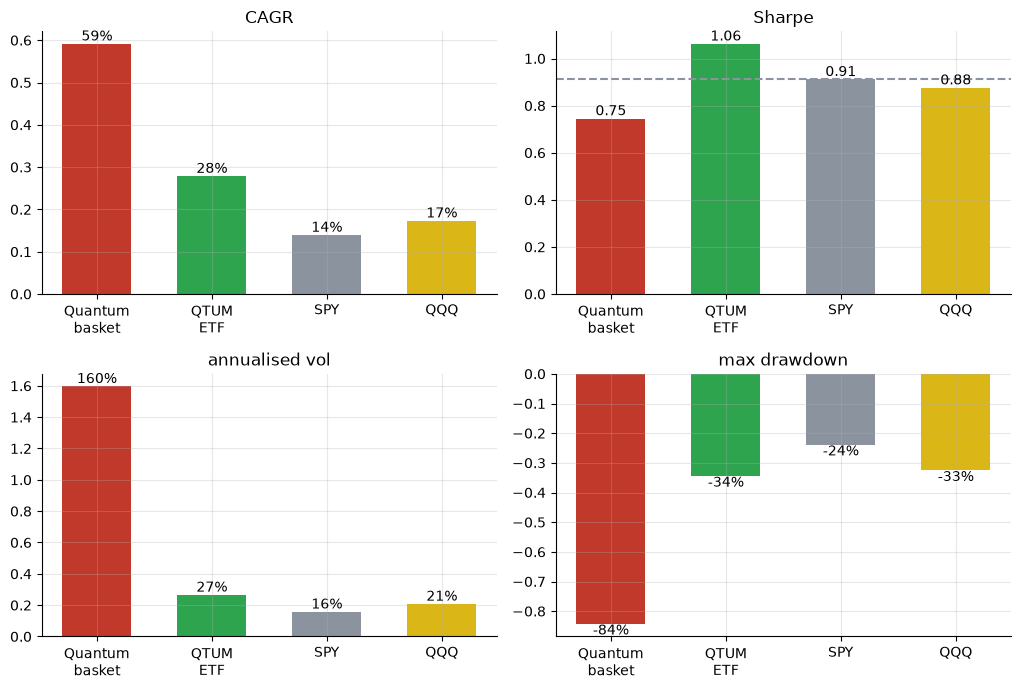

Sharpe basket/etf/spy/qqq: [0.75, 1.06, 0.91, 0.88]


In [2]:
legs = ['basket', 'etf', 'spy', 'qqq']; labs = ['Quantum\nbasket','QTUM\nETF','SPY','QQQ']
if HAVE_REAL:
    s = RACE['summ']
    cagr=[s[l]['cagr'] for l in legs]; sh=[s[l]['sharpe'] for l in legs]
    vol=[s[l]['vol'] for l in legs]; dd=[s[l]['max_dd'] for l in legs]
else:
    cagr=[R['basket'][0]/100,R['etf'][0]/100,R['spy'][0]/100,R['qqq'][0]/100]
    sh=[R['basket'][1],R['etf'][1],R['spy'][1],R['qqq'][1]]
    vol=[R['basket'][2]/100,R['etf'][2]/100,R['spy'][2]/100,R['qqq'][2]/100]
    dd=[R['basket'][3]/100,R['etf'][3]/100,R['spy'][3]/100,R['qqq'][3]/100]
x=np.arange(len(legs)); col=[RED,GREEN,GREY,AMBER]
fig,axs=plt.subplots(2,2,figsize=(10.4,7.0))
for ax,vals,title,fmt in [(axs[0,0],cagr,'CAGR','{:.0%}'),(axs[0,1],sh,'Sharpe','{:.2f}'),
                          (axs[1,0],vol,'annualised vol','{:.0%}'),(axs[1,1],dd,'max drawdown','{:.0%}')]:
    ax.bar(x,vals,color=col,width=.6); ax.set_xticks(x); ax.set_xticklabels(labs); ax.set_title(title)
    for i,v in enumerate(vals): ax.annotate(fmt.format(v),(i,v),ha='center',va='bottom' if v>=0 else 'top')
axs[0,1].axhline(sh[2],ls='--',c=GREY)
plt.tight_layout(); plt.show()
print('Sharpe basket/etf/spy/qqq:', [round(v,2) for v in sh])

> 💡 In plain words: the basket posts **+59%/yr** — and a **160% vol**, an **-84% drawdown**, and a **Sharpe of 0.75**, *below* SPY's 0.91 and well below QTUM's 1.06. H₂ is rejected on sight: the CAGR is leverage on beta plus a fat tail, not reward. The diversified ETF is the only leg with a *better* Sharpe than the index.

### 4b · The decisive test — is the spread even significant?

The basket's monthly spread over each benchmark under a Newey-West HAC standard error. A real edge clears t = 2; a hype cycle doesn't.

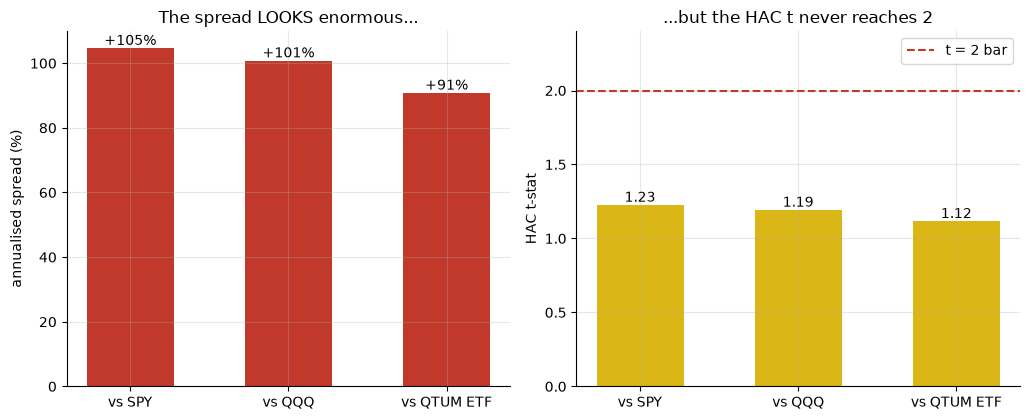

HAC t vs SPY/QQQ/QTUM: [1.23, 1.19, 1.12] -> none clears 2


In [3]:
if HAVE_REAL:
    tv = [RACE['test_vs_spy'], RACE['test_vs_qqq'], RACE['test_vs_etf']]
    spreads = [t['mean_diff_ann']*100 for t in tv]; ts = [t['tstat'] for t in tv]
else:
    spreads = [R['t_spy'][0], R['t_qqq'][0], R['t_etf'][0]]
    ts = [R['t_spy'][1], R['t_qqq'][1], R['t_etf'][1]]
labs = ['vs SPY','vs QQQ','vs QTUM ETF']; x=np.arange(3)
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.4,4.3))
a1.bar(x,spreads,color=RED,width=.55); a1.set_xticks(x); a1.set_xticklabels(labs)
a1.set_ylabel('annualised spread (%)'); a1.set_title('The spread LOOKS enormous...')
for i,v in enumerate(spreads): a1.annotate(f'+{v:.0f}%',(i,v),ha='center',va='bottom')
a2.bar(x,ts,color=AMBER,width=.55); a2.axhline(2,ls='--',c=RED,label='t = 2 bar')
a2.set_xticks(x); a2.set_xticklabels(labs); a2.set_ylabel('HAC t-stat'); a2.set_ylim(0,2.4)
a2.set_title('...but the HAC t never reaches 2'); a2.legend()
for i,v in enumerate(ts): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print('HAC t vs SPY/QQQ/QTUM:', [round(t,2) for t in ts], '-> none clears 2')

> 💡 In plain words: **+105%/yr vs SPY** at **t = 1.23** — the point estimate is gigantic, the standard error is gigantic too. A real edge pushes the *t* through 2; here it sits near 1.2 against *every* benchmark, including the diversified ETF. H₁ is **not rejected, not supported**: a huge whisper inside its own error bar, driven by a couple of melt-up months.

### 4c · One stock or four? — the single-name decomposition

Per-name HAC *t* of excess over SPY, with each name's own worst drawdown. If the basket were a real theme, *some* name would clear t = 2. None does — and all four are casino chips.

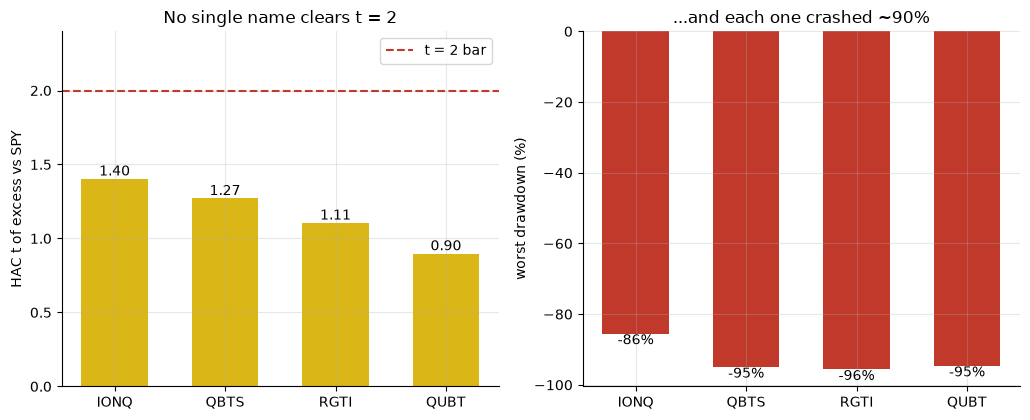

per-name HAC t: {'IONQ': 1.4, 'QBTS': 1.27, 'RGTI': 1.11, 'QUBT': 0.9}


In [4]:
names = list(R['names'].keys())
if HAVE_REAL:
    ts = [RACE['single_names'][n]['tstat'] for n in names]
    dd = [RACE['single_names'][n]['max_dd']*100 for n in names]
else:
    ts = [R['names'][n][4] for n in names]; dd = [R['names'][n][2] for n in names]
x=np.arange(len(names))
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.4,4.3))
a1.bar(x,ts,color=AMBER,width=.6); a1.axhline(2,ls='--',c=RED,label='t = 2 bar')
a1.set_xticks(x); a1.set_xticklabels(names); a1.set_ylabel('HAC t of excess vs SPY'); a1.set_ylim(0,2.4)
a1.set_title('No single name clears t = 2'); a1.legend()
for i,v in enumerate(ts): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a2.bar(x,dd,color=RED,width=.6); a2.set_xticks(x); a2.set_xticklabels(names)
a2.set_ylabel('worst drawdown (%)'); a2.set_title('...and each one crashed ~90%')
for i,v in enumerate(dd): a2.annotate(f'{v:.0f}%',(i,v),ha='center',va='top')
plt.tight_layout(); plt.show()
print('per-name HAC t:', {n: round(t,2) for n,t in zip(names,ts)})

> 💡 In plain words: the strongest name (IONQ) reaches just **t = 1.40**; the rest are lower, and every one drew down 95%-class. The basket is not one lucky moon-shot hiding three duds — it is **four** statistically-unproven lottery tickets that crash together. Pooling them cuts the *t* further (shared risk-off beta), it doesn't rescue it.

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic fat-tailed *hype basket*: with **zero** planted risk-adjusted edge (`edge_sharpe = 0`) each name has zero expected excess over the market, so the HAC *t* of the spread must stay at the null — the fat vol only adds noise; with a **+1.0 Sharpe** edge it must light up. Both hold.

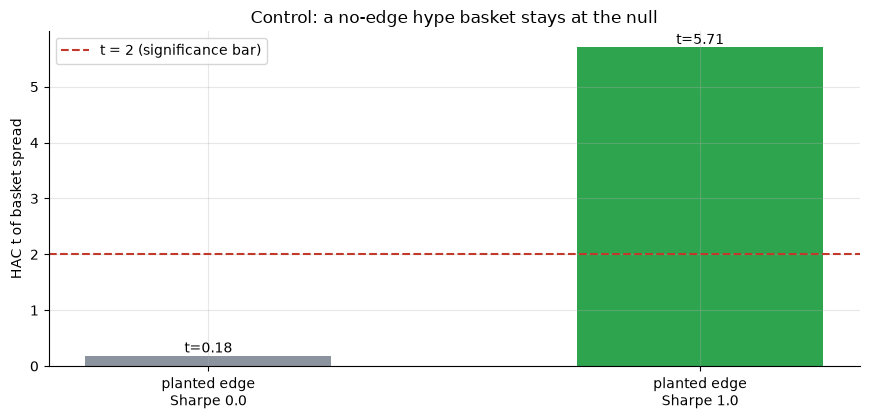

edge_sharpe=+0.0: CAGR=-11% Sharpe=0.23 spread=5%/yr t=0.18
edge_sharpe=+1.0: CAGR=256% Sharpe=2.05 spread=147%/yr t=5.71


In [5]:
res = []
for edge in (0.0, 1.0):
    rdf, b, truth = data.synthetic_panel(edge_sharpe=edge, seed=395)
    basket = st.basket_returns(rdf, truth['basket_cols'])
    sm = st.summarize(basket); t = st.hac_tstat_diff(basket, b)
    res.append((edge, sm['cagr']*100, sm['sharpe'], t['mean_diff_ann']*100, t['tstat']))
labels=[f'planted edge\nSharpe {e:.1f}' for e,_,_,_,_ in res]; tvals=[r[4] for r in res]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 (significance bar)')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('HAC t of basket spread'); ax.set_title('Control: a no-edge hype basket stays at the null'); ax.legend()
plt.tight_layout(); plt.show()
for e,c,s,sp,t in res: print(f'edge_sharpe={e:+.1f}: CAGR={c:.0f}% Sharpe={s:.2f} spread={sp:.0f}%/yr t={t:.2f}')

> 💡 In plain words: with **no** real edge the control sits at **t = 0.18** (below 2 — a fat-tailed basket *cannot* fake significance out of pure beta+noise); only a genuine **+1.0 Sharpe** edge reaches **t = 5.71**. So the machinery is honest, and the real-tape *t* of **1.23** is exactly what an *absent or tiny* risk-adjusted edge looks like through a 61-month, fat-tailed keyhole. The Sharpe and the *t*, together, are the verdict.

## 5 · The verdict

- **Signal `WEAK`** — basket−SPY spread **+105%/yr** at HAC **t = 1.23** (n = 61; 1.19 vs QQQ, 1.12 vs QTUM); **no name clears t = 2**; basket Sharpe **0.75** < SPY **0.91**. Literature support + a positive-but-insignificant, risk-unrewarded point estimate, survivorship-tilted over one regime ⇒ `WEAK`, not `REAL` (the t≥2 bar is not met).
- **Tradability `MIRAGE`** — **160% vol**, **-84% drawdown** (single names −86% to −96%); net of 10-bps costs the Sharpe is unchanged. **Risk**, not friction, makes it un-allocatable, and risk-adjusted it loses to SPY *and* the QTUM ETF (Sharpe 1.06). The +59%/yr is a number you could not have held through the −84% draw.
- **Next big thing? `HYPE-CYCLE`** — a real technology, no profits yet, a stock cohort with a giant CAGR, a giant drawdown, a sub-market Sharpe, and a sub-2 *t* a synthetic null reproduces from pure beta+noise (t = 0.18). The diversified ETF was the risk-rewarded way to play quantum all along — and even it is not a free lunch. [Study 393 (AI-Datacenter)](../393-ai-datacenter-basket/) in a pre-revenue costume.

## 6 · Could you trade it? — the holdability problem

The operational truth in one picture: the basket's underwater curve. A sleeve you spend most of the sample **down 50%+** from its high is not something a fund — or a human — actually holds to collect the headline CAGR.

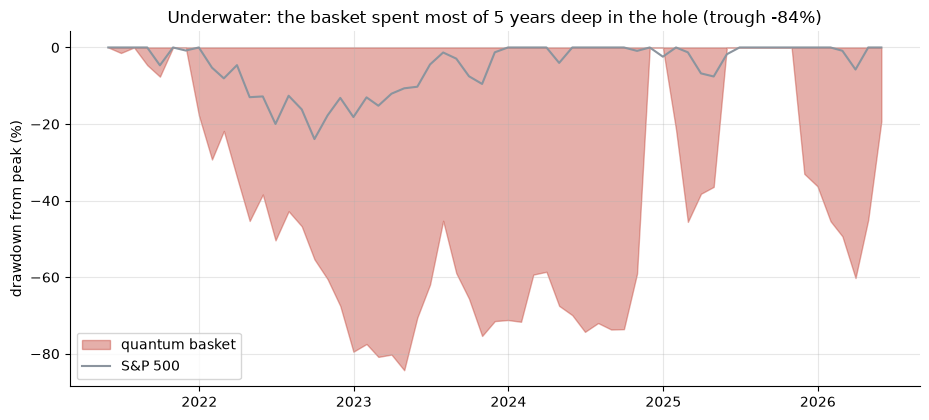

months >50% below peak: basket 44% of the sample vs SPY 0%


In [6]:
if HAVE_REAL:
    r = RACE['basket'].dropna(); rs = RACE['spy'].dropna()
    eq = (1+r).cumprod(); under = eq/eq.cummax()-1
    eqs = (1+rs).cumprod(); unders = eqs/eqs.cummax()-1
    fig, ax = plt.subplots(figsize=(9.4, 4.3))
    ax.fill_between(under.index, under.values*100, 0, color=RED, alpha=.4, label='quantum basket')
    ax.plot(unders.index, unders.values*100, color=GREY, lw=1.5, label='S&P 500')
    ax.set_ylabel('drawdown from peak (%)')
    ax.set_title(f'Underwater: the basket spent most of 5 years deep in the hole (trough {under.min()*100:.0f}%)')
    ax.legend(); plt.tight_layout(); plt.show()
    frac = float((under < -0.5).mean())
    print(f'months >50% below peak: basket {frac*100:.0f}% of the sample vs SPY {(unders<-0.5).mean()*100:.0f}%')
else:
    print('no cache — see docs/results.md: basket max drawdown -84.3% vs SPY -23.9%')

> 💡 In plain words: the red region is how far below its own high-water mark the basket was, month by month. It is deep and persistent — long stretches **>50% underwater** — while the index (grey) barely dips. The capacity question never even arises: **the path is the constraint.** No sizing, no cost regime, no rebalance schedule converts a 160%-vol, −84%-drawdown lottery into a NAV-scale holding. The rarity-of-edge that makes the thesis exciting is exactly the volatility that makes it untradable.

## 7 · Going further

- **The selection sibling.** [Study 393 — AI-Datacenter-Basket](../393-ai-datacenter-basket/): a thematic basket whose spread *is* significant on the tape but is *named in hindsight*. Reading them together separates the two thematic-basket traps — **ex-post selection** (393) vs **unrewarded risk + small sample** (here).
- **Disruptive-tech fund.** [Study 334 — ARK-Innovation](../334-ark-innovation/) — does riding "innovation" pay risk-adjusted? Same high-vol theme family.
- **Thematic commodity-equity.** [Study 302 — Lithium-Boom](../302-lithium-boom/) and [Study 303 — Uranium-Revival](../303-uranium-revival/) — real theme, the question is whether the *basket* harvests it net of risk.
- **Diversify the tail.** Re-run with the QTUM constituents or the mega-cap quantum efforts (GOOGL/IBM/MSFT) added; the idiosyncratic tail shrinks, the Sharpe rises toward the ETF's, and the "basket" stops being a lottery.

*The reproducible core is offline and deterministic; survivorship is explicit. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*